#### This notebook reproduces figure 4 in "Exceeding Human Heat Tolerance: Global Projections for a Warming, Aging World" by Kong et al.


In [1]:
"""
import python packages
please install required packages before running this notebook
"""
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import regionmask
import pandas as pd
import openpyxl
%matplotlib inline
%config InlineBackend.figure_format = "retina"

/home/kong97/.conda/envs/econ_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# directory to data; you might want to change it to your own directory
# directory to data; you might want to change it to your own directory
path='../data/'

#The number of young, middle-aged, and old people exposed in each individual country; for 15 climate models at 3°C warming
pop_exposed=xr.open_dataset(path+'Country_level_exposed_pop_num.nc').pop
# same as above but for total population of each age group
pop_total=xr.open_dataset(path+'Country_level_tot_pop_num.nc').pop
# get a list of countries and their abbreviations from regionmask
countries = np.array(regionmask.defined_regions.natural_earth_v4_1_0.countries_50.names)
abb=np.array(regionmask.defined_regions.natural_earth_v4_1_0.countries_50.abbrevs)

/tmp/ipykernel_944719/4173710289.py:11: UserWarning: `land_50` of `natural_earth_v4_1_0` and `natural_earth_v5_0_0` does not quite extend to 90°S - it's recommended to use `natural_earth_v5_1_2` instead. See https://github.com/regionmask/regionmask/issues/487
  countries = np.array(regionmask.defined_regions.natural_earth_v4_1_0.countries_50.names)


In [3]:
# fix abbreviation in regionmask: the abbreviations of some countries in regionmask are not two-letter.
abb[168]='AX'
abb[104]='EH'
abb[134]='JO'
abb[135]='JP'
abb[136]='JM'
abb[138]='IL'
abb[144]='IN'
abb[143]='ID'
abb[142]='IR'
abb[230]='AM'
abb[234]='AD'
abb[9]='FM'
abb[46]='SY'
abb[61]='SI'
abb[69]='SM'
abb[75]='RU'
abb[139]='PS'
abb[140]='IE'
abb[141]='IQ'
abb[169]='FI'
abb[172]='EE'
abb[191]='CD'
abb[212]='BA'
abb[5]='VA'
abb[48]='SE'
abb[54]='ES'
abb[78]='PT'
abb[88]='NO'
abb[112]='MT'
abb[119]='LU'
abb[137]='IT'
abb[156]='DE'
abb[160]='FR'
abb[217]='BE'
abb[224]='AT'

In [4]:
# this only select the countries within regionmask that also appear in my data
mask=np.isin(countries,pop_exposed.country.values)
indices=np.where(mask)[0]
abb=abb[indices]
countries=countries[indices]

In [5]:
# caclulate the the number and percent of people exposed to at least 180 hours of uncompensable heat annually in each individual countries
# for both all people and specific age groups at 3°C warming

def calc_num_percent_exposed(age):
    if age=='all': # all age groups
        num=pop_exposed.sum('age') # exposed number 
        percent=pop_exposed.sum('age')/pop_total.sum('age') # exposed percentage
    else: # a specific age group
        num=pop_exposed.sel(age=age) # exposed number
        percent=pop_exposed.sel(age=age)/pop_total.sel(age=age) # exposed percentage
    # eliminates countries/regions where there is no population
    country_index_nonan=np.where(~np.isnan(percent[:,0]))[0]
    num=num[country_index_nonan,:]
    percent=percent[country_index_nonan,:]
    abr=abb[country_index_nonan]
    # calculate model ensemble mean
    num=num.mean('model')
    percent=percent.mean('model')
    # change population number to log scale
    num=xr.where(num==0,0,np.log10(num))
    # only retain countries with >0 people exposed
    percent=percent[np.where(num>0)]
    abr=abr[np.where(num>0)]
    num=num[np.where(num>0)]
    return (num,percent,abr)

num_all,percent_all,abr_all=calc_num_percent_exposed('all')
num_old,percent_old,abr_old=calc_num_percent_exposed('old')

/home/kong97/.conda/envs/econ_env/lib/python3.11/site-packages/xarray/computation/apply_ufunc.py:820: RuntimeWarning: divide by zero encountered in log10
  result_data = func(*input_data)
/home/kong97/.conda/envs/econ_env/lib/python3.11/site-packages/xarray/computation/apply_ufunc.py:820: RuntimeWarning: divide by zero encountered in log10
  result_data = func(*input_data)


In [6]:
# read in poverty rate dataset
def read_poverty(poverty_line):
    # poverty line threshold: 3.0, 4.2 or 8.3 dollar per day
    if poverty_line==3:
        file='/scratch/bell/kong97/Tw_hothours_of_different_age_groups/data_for_publication/data/pip3.0.xlsx'
    elif poverty_line==4:
        file='/scratch/bell/kong97/Tw_hothours_of_different_age_groups/data_for_publication/data/pip4.2.xlsx'
    elif poverty_line==8:
        file='/scratch/bell/kong97/Tw_hothours_of_different_age_groups/data_for_publication/data/pip8.3.xlsx'
    df = pd.read_excel(file, engine='openpyxl')
    # only select years between 2016 and 2025
    df_filtered = df[(df['reporting_year'] >= 2016) & (df['reporting_year'] <= 2025)]
    # calculate the average poverty rate between 2016 and 2025
    mean_headcount = df_filtered.groupby(['country_name', 'country_code'])['headcount'].mean().reset_index()
    
    """
    some countries have different names in population exposure dataset and poverty dataset
    Here I adjust country names in poverty dataset to match the country names in population exposure dataset
    """
    mean_headcount['country_name'] = mean_headcount['country_name'].replace({
        'Viet Nam': 'Vietnam',
        'Russian Federation': 'Russia',
        'St. Lucia': 'Saint Lucia',
        'Yemen, Rep.': 'Yemen',
        'Micronesia, Fed. Sts.': 'Micronesia',
        'Marshall Islands': 'Marshall Is.',
        'United States':'United States of America',
        'South Sudan':'S. Sudan',
        'Korea, Rep.':'South Korea',
        'West Bank and Gaza':'Palestine',
        'Egypt, Arab Rep.':'Egypt',
        'Congo, Dem. Rep.':'Dem. Rep. Congo',
        'Congo, Rep.':'Congo',
        'Central African Republic':'Central African Rep.',
        "Cote d'Ivoire":"Côte d'Ivoire",
        'Syrian Arab Republic':'Syria',
        'Iran, Islamic Rep.':'Iran',
        'Gambia, The':'Gambia',
        'Lao PDR':'Laos',
        'Turkiye':'Turkey',
        'Solomon Islands':'Solomon Is.',
        'Sao Tome and Principe':'São Tomé and Principe',
        'Equatorial Guinea':'Eq. Guinea',
        'Dominican Republic':'Dominican Rep.',
    })
    """
    Some countries in population exposure dataset are not available in poverty dataset
    To solve this, I identify analog countries for them assuming they share similar poverty rates with their analogs
    """
    new_countries = {
        'Venezuela': 'Colombia',
        'N. Mariana Is.': 'Philippines',
        'U.S. Virgin Is.': 'United States of America',
        'Guam': 'Philippines',
        'American Samoa': 'Samoa',
        'Puerto Rico': 'United States of America',
        'Anguilla': 'Trinidad and Tobago',
        'Cayman Is.': 'Jamaica',
        'Bermuda': 'United Kingdom',
        'British Virgin Is.': 'Trinidad and Tobago',
        'Turks and Caicos Is.': 'Jamaica',
        'Montserrat': 'Jamaica',
        'Somalia': 'S. Sudan',
        'Singapore': 'Malaysia',
        'Saudi Arabia': 'United Arab Emirates',
        'St. Kitts and Nevis': 'Grenada',
        'Palau': 'Micronesia',
        'Oman': 'United Arab Emirates',
        'North Korea': 'Laos',
        'New Zealand': 'Australia',
        'Aruba': 'Trinidad and Tobago',
        'Curaçao': 'Trinidad and Tobago',
        'W. Sahara': 'Morocco',
        'Libya': 'Egypt',
        'Kuwait': 'Qatar',
        'Wallis and Futuna Is.': 'Fiji',
        'St-Martin': 'Dominican Rep.',
        'St-Barthélemy': 'Dominican Rep.',
        'Eritrea': 'Ethiopia',
        'Cuba': 'Dominican Rep.',
        'Cambodia': 'Laos',
        'Brunei': 'Malaysia',
        'Bahrain': 'Qatar',
        'Bahamas': 'Barbados',
        'Antigua and Barb.': 'Grenada',
        'Afghanistan': 'Yemen',
        'Sint Maarten': 'Dominican Rep.',
        'St. Vin. and Gren.': 'Jamaica',
        'Dominica':'Saint Lucia',
        'Cook Is.': 'Fiji',
        'Niue':'Australia',
        'Fr. Polynesia':'France',
        'New Caledonia':'France'
    }

    
    # Create a new list of rows to append
    new_rows = []
    for new_country, analog in new_countries.items():
        # Find analog value
        analog_row = mean_headcount[mean_headcount['country_name'] == analog]
        if not analog_row.empty:
            headcount_value = analog_row['headcount'].values[0]
            new_rows.append({
                'country_name': new_country,
                'country_code': 'XXX',
                'headcount': headcount_value
            })
        else:
            print(f"Analog country '{analog}' not found in the dataframe!")
    df_new = pd.DataFrame(new_rows)
    df_combined = pd.concat([mean_headcount, df_new])
    # create poverty ratio xarray of the same dimension and coords as the exposed population number and percent variable
    poverty_ratio=num_all*0-999
    for c in poverty_ratio['country'].values:
        poverty_ratio[poverty_ratio['country']==c]=df_combined[df_combined['country_name']==c]['headcount'].values.item()
    return poverty_ratio

poverty_ratio8=read_poverty(8) # $8.3 per day in 2021 Purchasing Power Parities

In [7]:
# create colormap
colors=np.array([
    [8,48,107],
    [8,81,156],
    [33,113,181],
    [66,146,198],
    [107,174,214],
    [251,106,74],
    [239,59,44],
    [203,24,29],
    [165,15,21],
    [103,0,13],
])
cmap=mpl.colors.ListedColormap(colors/255.)

In [8]:
# assign color to countries according to their poverty ratios
def getcolor(ratio):
    if ratio<0.1:
        color = tuple(c/255 for c in colors[0])
    elif ratio>=0.1 and ratio<0.2:
        color = tuple(c/255 for c in colors[1])
    elif ratio>=0.2 and ratio<0.3:
        color = tuple(c/255 for c in colors[2])
    elif ratio>=0.3 and ratio<0.4:
        color = tuple(c/255 for c in colors[3])
    elif ratio>=0.4 and ratio<0.5:
        color = tuple(c/255 for c in colors[4])
    elif ratio>=0.5 and ratio<0.6:
        color = tuple(c/255 for c in colors[5])
    elif ratio>=0.6 and ratio<0.7:
        color = tuple(c/255 for c in colors[6])
    elif ratio>=0.7 and ratio<0.8:
        color = tuple(c/255 for c in colors[7])
    elif ratio>=0.8 and ratio<0.9:
        color = tuple(c/255 for c in colors[8])
    elif ratio>=0.9:
        color = tuple(c/255 for c in colors[9])
    return color

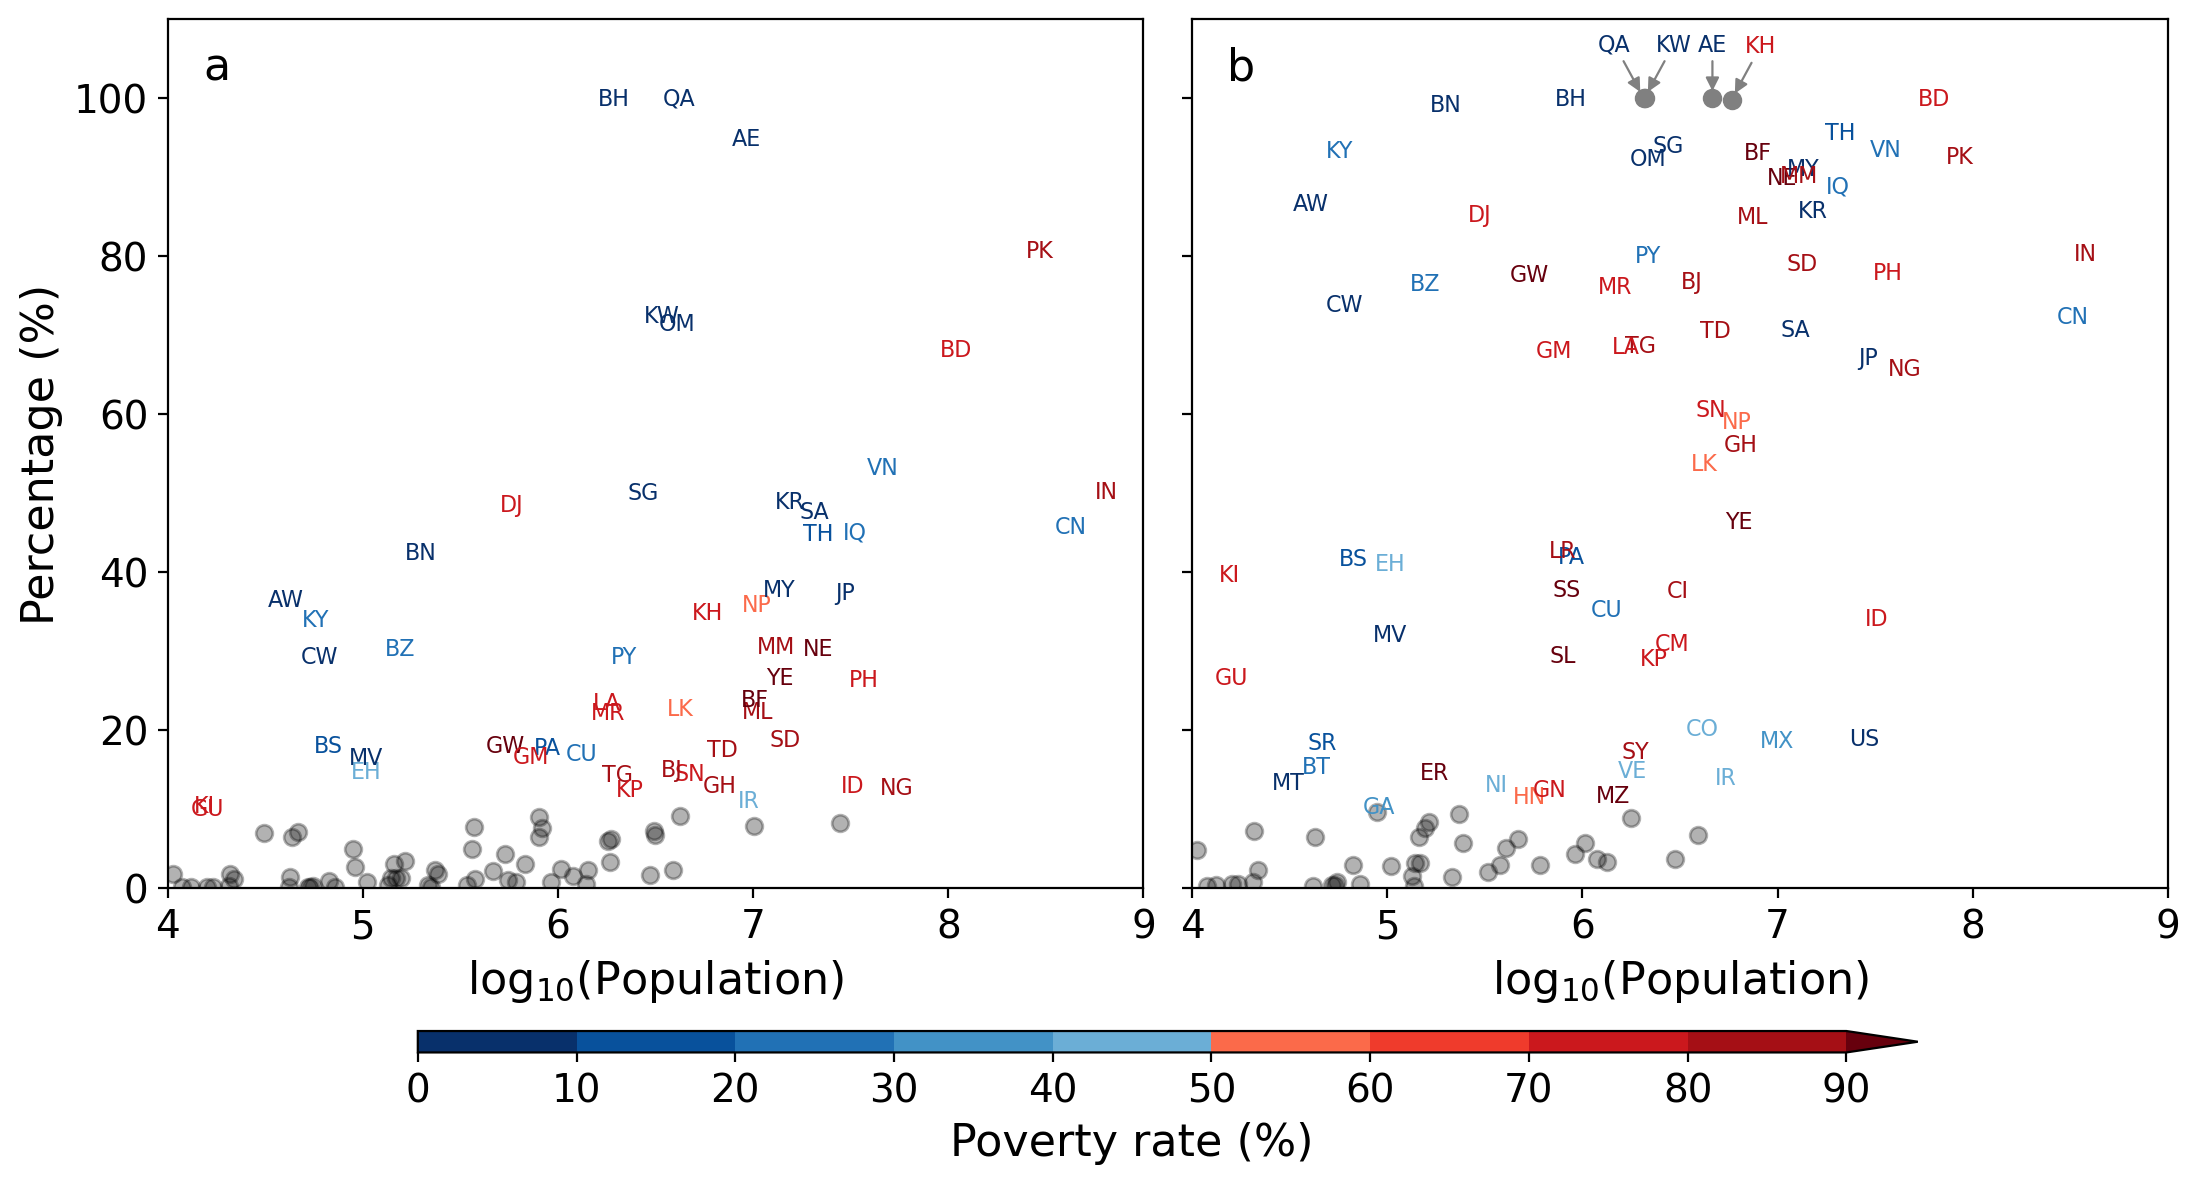

In [9]:
fig = plt.figure(figsize=(10,5.5))
ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122)

annots=['a','b']
anno_opts = dict(xy=(0.05, 0.93), xycoords='axes fraction',va='baseline', ha='center')
j=0
for ax in [ax1,ax2]:
    ax.tick_params(axis='both', labelsize=14)
    ax.annotate(annots[j], **anno_opts,fontsize=16)  
    ax.set_xlim(0.95,4.05)
    j+=1

xs=[num_all,num_old] # x variable: exposed population number for all age groups and the elderly 
ys=[percent_all,percent_old] # y variable: the percent of population exposed for all age groups and the elderly
abrs=[abr_all,abr_old] # country abbreviations
axs=[ax1,ax2]

for j in range(2): # loop over age groups: all and elderly
    for k in range(len(xs[j])): # loop over countries
        ratio = poverty_ratio8[k].values  # get poverty value for this country
        color = getcolor(ratio)  # map ratio to color
        if xs[j][k]<4 or ys[j][k]<0.1: # plot countries with less than 10% or 10,000 people exposed as scatters 
            axs[j].scatter(xs[j][k].item(), ys[j][k].item(),c='k',alpha=0.3)
            
        # special treatment to KW, QA, AE, and KH for more clear visualization
        elif j==1 and abrs[j][k] in ['KW']:
            axs[j].scatter(xs[j][k].item(), ys[j][k].item(),c='gray')
            axs[j].annotate('KW', xy=(xs[j][k].item(), ys[j][k].item()), 
                            xytext=(xs[j][k].item() + 0.15, ys[j][k].item() + 0.06),color=color,
                            arrowprops=dict(arrowstyle='-|>', color='gray', lw=0.8, shrinkA=0, shrinkB=2.5,mutation_scale=10),
                            fontsize=8, ha='center')
        elif j==1 and abrs[j][k] in ['QA']:
            axs[j].scatter(xs[j][k].item(), ys[j][k].item(),c='gray')
            axs[j].annotate('QA', xy=(xs[j][k].item(), ys[j][k].item()), 
                            xytext=(xs[j][k].item() - 0.15, ys[j][k].item() + 0.06),color=color,
                            arrowprops=dict(arrowstyle='-|>', color='gray', lw=0.8, shrinkA=0, shrinkB=2.5,mutation_scale=10),
                            fontsize=8, ha='center')
        elif j==1 and abrs[j][k] in ['AE']:
            axs[j].scatter(xs[j][k].item(), ys[j][k].item(),c='gray')
            axs[j].annotate('AE', xy=(xs[j][k].item(), ys[j][k].item()), 
                            xytext=(xs[j][k].item(), ys[j][k].item() + 0.06),color=color,
                            arrowprops=dict(arrowstyle='-|>', color='gray', lw=0.8, shrinkA=0, shrinkB=2.5,mutation_scale=10),
                            fontsize=8, ha='center')
        elif j==1 and abrs[j][k] in ['KH']:
            axs[j].scatter(xs[j][k].item(), ys[j][k].item(),c='gray')
            axs[j].annotate('KH', xy=(xs[j][k].item(), ys[j][k].item()), 
                            xytext=(xs[j][k].item() + 0.15, ys[j][k].item() + 0.06),color=color,
                            arrowprops=dict(arrowstyle='-|>', color='gray', lw=0.8, shrinkA=0, shrinkB=2.5,mutation_scale=10),
                            fontsize=8, ha='center')
        else: # for other contries, directly plot the ISO two-letter country code
            g=axs[j].text(xs[j][k].item(), ys[j][k].item(), abrs[j][k], color=color,fontsize=8, ha='center', va='center')
    axs[j].set_xlim(4, 9)
    axs[j].set_ylim(0, 1.1)
    axs[j].tick_params(axis='both', labelsize=14)

ax1.set_xlabel('log$_{10}$(Population)',fontsize=16)
ax2.set_xlabel('log$_{10}$(Population)',fontsize=16)
ax1.set_ylabel('Percentage (%)',fontsize=16)

ax1.set_yticks([0,0.2,0.4,0.6,0.8,1])
ax2.set_yticks([0,0.2,0.4,0.6,0.8,1])
ax1.set_yticklabels(['0','20','40','60','80','100'])

ax2.set_yticklabels([])

fig.subplots_adjust(bottom=0, left=0,right=1, top=1,hspace=0.18,wspace=0.05)

# plot colorbar
boundaries = np.arange(0, 91, 10)/10
norm = mpl.colors.BoundaryNorm(boundaries=boundaries, ncolors=10, extend='max')

sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cb = fig.colorbar(sm, ax=(ax1, ax2),
                  orientation='horizontal', pad=0.13, shrink=0.75,
                  fraction=.08, aspect=70, extend='max')

cb.set_ticks(boundaries) 
tick_labels = ['0', '10', '20', '30', '40', '50', '60', '70', '80', '90']
cb.set_ticklabels(tick_labels)

cb.set_label(label='Poverty rate (%)', size=16)
cb.ax.tick_params(labelsize=14)

**Figure 4**: The number (x-axis on a log-scale) and percentage (y-axis) of total population (a) and the
elderly (b) experiencing at least 180 hours of UHS annually within individual countries (denoted by
scatter points or ISO two-letter country codes) at 3°C warming relative to the preindustrial period.